# 01 - E1: BiLSTM baseline

Notebook này huấn luyện một BiLSTM từ đầu cho bài toán gán nhãn dấu câu
theo từ. E1 đóng vai trò baseline để đánh giá lợi ích của pretrained
language model trong các thí nghiệm E2-E4

Model học trên `train.jsonl`; checkpoint được chọn bằng Punctuation
Macro-F1 của `validation.jsonl`. Official test không tham gia quá trình
huấn luyện hoặc lựa chọn checkpoint. Kết quả được lưu tại
`outputs/experiments/E1/` và `outputs/checkpoints/E1/`


In [ ]:
import os, sys, json, time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "src").exists(), f"Cannot locate the repo root from {Path.cwd()}"
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd

from src.data.constants import (
    LABELS, LABEL2ID, PUNCTUATION_LABELS, MONITOR_METRIC,
    PROCESSED_FILES, OUTPUT_DATA_DIR, CHECKPOINT_DIR, EXPERIMENT_DIR, SEED,
)
from src.data.dataset import load_examples
from src.evaluation.evaluator import predict_word_labels, sample_predictions
from src.evaluation.metrics import format_metrics_table
from src.models.factory import load_model_from_checkpoint
from src.training.seed import set_seed
from src.utils.environment import collect_environment, format_environment
from src.utils.io import read_json, read_yaml
from src.utils.logging_utils import configure_stdout_utf8

configure_stdout_utf8()

EXPERIMENT_ID = "E1"
CONFIG_PATH   = PROJECT_ROOT / "configs" / "e1_bilstm.yaml"

print(f"Project root : {PROJECT_ROOT}")
print(f"Experiment   : {EXPERIMENT_ID}")
print(f"Config       : {CONFIG_PATH.relative_to(PROJECT_ROOT)}\n")
print(format_environment())

Project root : <USER_HOME>/Documents\GitHub\NLPgrSix7
Experiment   : E1
Config       : configs\e1_bilstm.yaml

Python version      : 3.12.4
Platform            : Windows-11-10.0.26100-SP0
PyTorch version     : 2.13.0+cu126
CUDA available      : True
CUDA runtime        : 12.6
GPU name            : NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory (GB)     : 8.0
Transformers version: 5.14.1
NumPy version       : 2.5.1


## 1. Chuẩn bị dữ liệu

Dữ liệu đến từ [JointCapPunc](https://github.com/ductho9799/JointCapPunc),
được cố định tại commit `ee258cae0e95e64245428d59ebbb030280fcebec`. Notebook
đọc `train.jsonl` để huấn luyện và `validation.jsonl` để đánh giá sau mỗi
epoch. Split test không được nạp ở giai đoạn này

Pipeline trước đó đã chuẩn hóa Unicode NFC, ánh xạ `QMARK` thành `QUESTION`,
chia chuỗi thành các mẫu không quá 150 từ và loại bản ghi trùng trong từng
split. Hash nội dung của dữ liệu được lưu cùng artifact và checkpoint để có
thể đối chiếu nguồn dữ liệu giữa các thí nghiệm


In [ ]:
config = read_yaml(CONFIG_PATH)

data_cfg = config["data"]
assert "test" not in json.dumps(data_cfg), "test split must not appear in the training config"
print("Files this notebook is allowed to read:")
print("  train      :", data_cfg["train_file"])
print("  validation :", data_cfg["validation_file"])
print("  test       : NOT LOADED  <-- reserved for Phase 2\n")

data_hashes = read_json(OUTPUT_DATA_DIR / "data_hashes.json")
for split in ("train", "validation"):
    h = data_hashes[split]
    print(f"  {split:<11} {h['num_examples']:>7,} examples  "
          f"{h['num_tokens']:>11,} tokens  content_sha256={h['content_sha256'][:16]}…")

set_seed(int(config["training"]["seed"]))

t0 = time.time()
train_examples      = load_examples(PROCESSED_FILES["train"])
validation_examples = load_examples(PROCESSED_FILES["validation"])
print(f"\nLoaded {len(train_examples):,} train / {len(validation_examples):,} validation "
      f"examples in {time.time() - t0:.1f}s")

Files this notebook is allowed to read:
  train      : data/processed/train.jsonl
  validation : data/processed/validation.jsonl
  test       : NOT LOADED  <-- reserved for Phase 2

  train        38,066 examples    4,940,478 tokens  content_sha256=138983bc2761546f…
  validation   15,227 examples    1,977,406 tokens  content_sha256=874133954b31fbfd…
2026-08-09 21:44:39 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 21:44:42 | INFO    | src.data.dataset | Loaded 38066 examples from train.jsonl
2026-08-09 21:44:43 | INFO    | src.data.dataset | Loaded 15227 examples from validation.jsonl

Loaded 38,066 train / 15,227 validation examples in 3.4s


In [ ]:
stats = read_json(OUTPUT_DATA_DIR / "data_statistics.json")

rows = []
for split in ("train", "validation"):
    s = stats["splits"][split]
    row = {"split": split, "examples": s["num_examples"], "tokens": s["num_tokens"],
           "mean_len": round(s["mean_length"], 1), "max_len": s["max_length"]}
    for lab in LABELS:
        row[f"%{lab}"] = round(100 * s["label_ratios"][lab], 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("split"))

ex = train_examples[0]
print("\nVí dụ một dòng dữ liệu (10 từ đầu):")
for tok, lab in list(zip(ex.tokens, ex.labels))[:10]:
    print(f"   {tok:<14} -> {lab}")
print(f"   … tổng cộng {len(ex.tokens)} từ, id={ex.id}, source_id={ex.source_id}")

,examples,tokens,mean_len,max_len,%O,%COMMA,%PERIOD,%QUESTION
split,,,,,,,,
train,38066,4940478,129.8,150,91.101,4.616,3.728,0.556
validation,15227,1977406,129.9,150,91.058,4.643,3.743,0.556



Ví dụ một dòng dữ liệu (10 từ đầu):
   hơn            -> O
   2              -> O
   tháng          -> O
   qua            -> O
   amidan         -> O
   khẩu           -> O
   cái            -> O
   của            -> O
   em             -> O
   có             -> O
   … tổng cộng 93 từ, id=train_000001, source_id=train_seg_000001


## 2. Mô hình BiLSTM

E1 sử dụng embedding học từ dữ liệu, BiLSTM hai chiều, dropout và một
lớp tuyến tính cho bốn nhãn. Ngữ cảnh hai chiều cho phép dự đoán dấu câu
sau một từ dựa trên cả phần đứng trước và phần đứng sau từ đó

`pack_padded_sequence` loại các vị trí padding khỏi phép tính hồi quy.
Điều này đặc biệt quan trọng với chiều backward của LSTM, vì padding ở
cuối chuỗi không nên ảnh hưởng biểu diễn của các từ thật


## 3. Xây dựng vocabulary

Vocabulary được xây dựng hoàn toàn từ training split để validation vẫn
phản ánh dữ liệu chưa quan sát. `<PAD>` có id 0 và dùng để đệm batch;
`<UNK>` có id 1 và đại diện cho token không có trong vocabulary

BiLSTM làm việc trực tiếp ở mức từ nên `tokens[i]` tương ứng với
`labels[i]`. Chỉ các vị trí padding nhận nhãn `-100` và bị bỏ qua khi
tính loss


In [ ]:
from src.data.dataset import Vocabulary

vocab = Vocabulary.build(
    train_examples,
    min_freq=int(config["data"].get("vocab_min_freq", 1)),
    max_size=config["data"].get("vocab_max_size"),
    source_split="train",
)

unk_rate = vocab.unk_rate(validation_examples)
print(f"Vocabulary size          : {len(vocab):,}  (bao gồm <PAD>=0, <UNK>=1)")
print(f"<UNK> rate on validation : {unk_rate:.4%}")
print(f"10 từ phổ biến nhất      : {vocab.itos[2:12]}")

demo = train_examples[0]
print("\nMã hoá 8 từ đầu của ví dụ đầu tiên:")
for tok, wid, lab in list(zip(demo.tokens, vocab.encode(demo.tokens), demo.labels))[:8]:
    print(f"   {tok:<14} -> id {wid:<7} label {lab} (={LABEL2ID[lab]})")

2026-08-09 21:44:43 | INFO    | src.data.dataset | Built vocabulary from train: 31615 types (min_freq=1, 31613 distinct words seen)
Vocabulary size          : 31,615  (bao gồm <PAD>=0, <UNK>=1)
<UNK> rate on validation : 0.4339%
10 từ phổ biến nhất      : ['có', 'em', 'không', 'và', 'bác', 'sĩ', 'bạn', 'là', 'bệnh', 'thể']

Mã hoá 8 từ đầu của ví dụ đầu tiên:
   hơn            -> id 81      label O (=0)
   2              -> id 84      label O (=0)
   tháng          -> id 95      label O (=0)
   qua            -> id 216     label O (=0)
   amidan         -> id 753     label O (=0)
   khẩu           -> id 971     label O (=0)
   cái            -> id 577     label O (=0)
   của            -> id 19      label O (=0)


## 4. Hàm mất mát

E1 dùng `CrossEntropyLoss(weight=None, ignore_index=-100)`. Không có
class weight; các vị trí padding bị loại khỏi loss thông qua
`ignore_index`

Cấu hình này cung cấp một baseline không điều chỉnh mất cân bằng lớp.
Kết quả theo từng lớp, đặc biệt precision và recall của `QUESTION`, sẽ
cho biết BiLSTM xử lý lớp hiếm đến mức nào


In [ ]:
from src.training.losses import get_class_weight_vector, load_class_weights

class_weights_blob = load_class_weights()
weight_mode        = config["loss"]["weight_mode"]
weight_vector      = get_class_weight_vector(weight_mode, class_weights=class_weights_blob)

print(f"weight_mode  : {weight_mode}")
print(f"nguồn trọng số: {class_weights_blob['source_split']} split "
      f"({class_weights_blob['total_train_tokens']:,} tokens)\n")

table = []
for i, lab in enumerate(LABELS):
    table.append({
        "label": lab,
        "train_count": class_weights_blob["counts"][lab],
        "train_share_%": round(100 * class_weights_blob["frequencies"][lab], 3),
        "inverse": round(class_weights_blob["inverse"][lab], 4),
        "sqrt_inverse": round(class_weights_blob["sqrt_inverse"][lab], 4),
        "USED HERE": "1.0 (none)" if weight_vector is None else round(weight_vector[i], 4),
    })
display(pd.DataFrame(table).set_index("label"))

weight_mode  : none
nguồn trọng số: train split (4,940,478 tokens)



,train_count,train_share_%,inverse,sqrt_inverse,USED HERE
label,,,,,
O,4500812,91.101,0.2744,0.5239,1.0 (none)
COMMA,228032,4.616,5.4164,2.3273,1.0 (none)
PERIOD,184186,3.728,6.7058,2.5896,1.0 (none)
QUESTION,27448,0.556,44.9985,6.7081,1.0 (none)


## 5. Cấu hình huấn luyện

Các tham số được đọc từ `configs/e1_bilstm.yaml`:

| Tham số | Giá trị |
|---|---|
| Epoch | 12 |
| Train batch size | 128 |
| Evaluation batch size | 256 |
| Optimizer | AdamW |
| Learning rate | `1e-3` |
| Weight decay | `1e-4` |
| Gradient clipping | 1.0 |
| Scheduler | `ReduceLROnPlateau` |
| Dropout | 0.30 |
| Seed | 42 |

Scheduler theo dõi validation Punctuation Macro-F1 và giảm learning
rate khi metric không còn cải thiện


In [ ]:
def flatten(prefix, obj, out):
    for k, v in obj.items():
        key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict):
            flatten(key, v, out)
        else:
            out.append({"parameter": key, "value": v})
    return out

display(pd.DataFrame(flatten("", config, [])).set_index("parameter"))

,value
parameter,
experiment.id,E1
experiment.name,BiLSTM baseline
experiment.description,Word-level BiLSTM tagger trained from scratch ...
model.type,bilstm
model.embedding_dim,128
model.hidden_size,128
model.num_layers,1
model.dropout,0.3
model.num_labels,4


## 6. Huấn luyện

Trong mỗi batch, model tạo logits theo từ, tính cross entropy trên các
vị trí hợp lệ, lan truyền ngược và clip gradient norm ở 1.0 trước khi
cập nhật optimizer. E1 không dùng gradient accumulation

Validation được chạy sau mỗi epoch. Trainer ghi training history và
chỉ cập nhật checkpoint khi validation Punctuation Macro-F1 vượt kết
quả tốt nhất trước đó


In [ ]:
from src.training.trainer_bilstm import build_bilstm_trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

trainer, vocab = build_bilstm_trainer(
    config,
    train_examples,
    validation_examples,
    vocab=vocab,
    data_hashes=data_hashes,
    device=device,
)

n_params = sum(p_.numel() for p_ in trainer.model.parameters())
print(f"\nModel parameters : {n_params:,} ({n_params / 1e6:.2f}M)")
print(f"Train batches/epoch : {len(trainer.train_loader):,}")
print(f"Val batches/epoch   : {len(trainer.validation_loader):,}")
print(f"Epochs              : {trainer.epochs}")

Device: cuda
2026-08-09 21:44:43 | INFO    | src.training.seed | Seed set to 42 (deterministic=False)
2026-08-09 21:44:43 | INFO    | src.training.losses | Loss: CrossEntropyLoss(weight_mode=none, weights=None, ignore_index=-100)
2026-08-09 21:44:45 | INFO    | src.training.optimizer | AdamW(lr=0.001, weight_decay=0.0001, betas=(0.9, 0.999), eps=1e-08) — 4,311,940 decayed / 0 not decayed params
2026-08-09 21:44:45 | INFO    | src.training.scheduler | Scheduler: ReduceLROnPlateau(mode=max, factor=0.5, patience=1) on validation punctuation_macro_f1

Model parameters : 4,311,940 (4.31M)
Train batches/epoch : 298
Val batches/epoch   : 60
Epochs              : 12


In [ ]:
result = trainer.fit()

print("\n" + "=" * 78)
print(f"TRAINING FINISHED — best epoch {result.best_epoch}, "
      f"validation {MONITOR_METRIC} = {result.best_score:.6f}")
print(f"Total time: {result.total_seconds / 60:.1f} min")
print("=" * 78)

2026-08-09 21:44:45 | INFO    | src.training.trainer_base | === E1: training for 12 epoch(s) on cuda (AMP=False) ===


E1 epoch 1 train:   0%|          | 0/298 [00:00<?, ?it/s]

2026-08-09 21:44:51 | INFO    | src.training.trainer_bilstm | epoch 1 step 100/298 — loss 0.4557
2026-08-09 21:44:55 | INFO    | src.training.trainer_bilstm | epoch 1 step 200/298 — loss 0.3714


E1 epoch 1 validation:   0%|          | 0/60 [00:00<?, ?it/s]

2026-08-09 21:45:02 | INFO    | src.training.checkpointing | Epoch 1: new best punctuation_macro_f1=0.406268 (was -inf) — checkpoint written to outputs\checkpoints\E1

[E1] epoch 1/12 (0.3 min) — train_loss=0.3261 val_loss=0.2163 val_PUNCT_F1=0.4063  <-- new best
label       precision    recall        f1     support
-----------------------------------------------------
O              0.9372    0.9924    0.9640   1,800,593
COMMA          0.5710    0.1570    0.2463      91,818
PERIOD         0.7484    0.3895    0.5124      74,008
QUESTION       0.5929    0.3759    0.4601      10,987
-----------------------------------------------------
accuracy       0.9277
macro F1       0.5457   (all 4 classes)
PUNCT-F1       0.4063   <-- model selection metric (COMMA/PERIOD/QUESTION)


...

2026-08-09 21:47:52 | INFO    | src.training.checkpointing | Epoch 11: new best punctuation_macro_f1=0.628241 (was 0.628161) — checkpoint written to outputs\checkpoints\E1

[E1] epoch 11/12 (0.3 min) — train_loss=0.1368 val_loss=0.1585 val_PUNCT_F1=0.6282  <-- new best
label       precision    recall        f1     support
-----------------------------------------------------
O              0.9618    0.9867    0.9741   1,800,593
COMMA          0.6599    0.3979    0.4964      91,818
PERIOD         0.7397    0.6403    0.6865      74,008
QUESTION       0.7086    0.6952    0.7018      10,987
-----------------------------------------------------
accuracy       0.9448
macro F1       0.7147   (all 4 classes)
PUNCT-F1       0.6282   <-- model selection metric (COMMA/PERIOD/QUESTION)


E1 epoch 12 train:   0%|          | 0/298 [00:00<?, ?it/s]

2026-08-09 21:47:57 | INFO    | src.training.trainer_bilstm | epoch 12 step 100/298 — loss 0.1321
2026-08-09 21:48:02 | INFO    | src.training.trainer_bilstm | epoch 12 step 200/298 — loss 0.1327


E1 epoch 12 validation:   0%|          | 0/60 [00:00<?, ?it/s]

2026-08-09 21:48:08 | INFO    | src.training.checkpointing | Epoch 12: punctuation_macro_f1=0.626214 did not beat best=0.628241 (epoch 11) — not saving

[E1] epoch 12/12 (0.3 min) — train_loss=0.1329 val_loss=0.1582 val_PUNCT_F1=0.6262
label       precision    recall        f1     support
-----------------------------------------------------
O              0.9614    0.9870    0.9741   1,800,593
COMMA          0.6506    0.4110    0.5037      91,818
PERIOD         0.7547    0.6285    0.6858      74,008
QUESTION       0.7524    0.6356    0.6891      10,987
-----------------------------------------------------
accuracy       0.9449
macro F1       0.7132   (all 4 classes)
PUNCT-F1       0.6262   <-- model selection metric (COMMA/PERIOD/QUESTION)

TRAINING FINISHED — best epoch 11, validation punctuation_macro_f1 = 0.628241
Total time: 3.4 min


## 7. Đánh giá trên validation

Metric dùng để chọn checkpoint là Punctuation Macro-F1:

$$
\text{Punctuation Macro-F1}
= \frac{F1_{COMMA} + F1_{PERIOD} + F1_{QUESTION}}{3}
$$

Lớp `O` không được đưa vào metric chính vì chiếm hơn 91% số token. Cách tính
macro cũng giúp `QUESTION`, lớp hiếm nhất, có vai trò ngang với `COMMA` và
`PERIOD`. Accuracy, macro-F1 bốn lớp, precision và recall vẫn được lưu để phân
tích nhưng không quyết định checkpoint


In [ ]:
best_metrics = trainer.checkpoints.best_metrics
artifacts    = trainer.artifacts

artifacts.write_best_validation(best_metrics, best_epoch=result.best_epoch)
artifacts.write_per_class(best_metrics)
artifacts.write_confusion_matrix(best_metrics)
artifacts.write_history()

print(f"Best epoch                 : {result.best_epoch}")
print(f"Validation PUNCT Macro-F1  : {best_metrics['punctuation_macro_f1']:.6f}")
print(f"Validation accuracy        : {best_metrics['accuracy']:.6f}")
print(f"Validation macro-F1 (4 cls): {best_metrics['macro_f1']:.6f}")
print(f"Supervised tokens scored   : {best_metrics['num_evaluated_tokens']:,}")

Best epoch                 : 11
Validation PUNCT Macro-F1  : 0.628241
Validation accuracy        : 0.944757
Validation macro-F1 (4 cls): 0.714699
Supervised tokens scored   : 1,977,406


## 8. Theo dõi quá trình huấn luyện

Biểu đồ bên trái đối chiếu train loss và validation loss theo epoch. Biểu đồ
bên phải theo dõi validation Punctuation Macro-F1 cùng macro-F1 trên bốn lớp;
epoch có metric chính cao nhất được đánh dấu là checkpoint tốt nhất


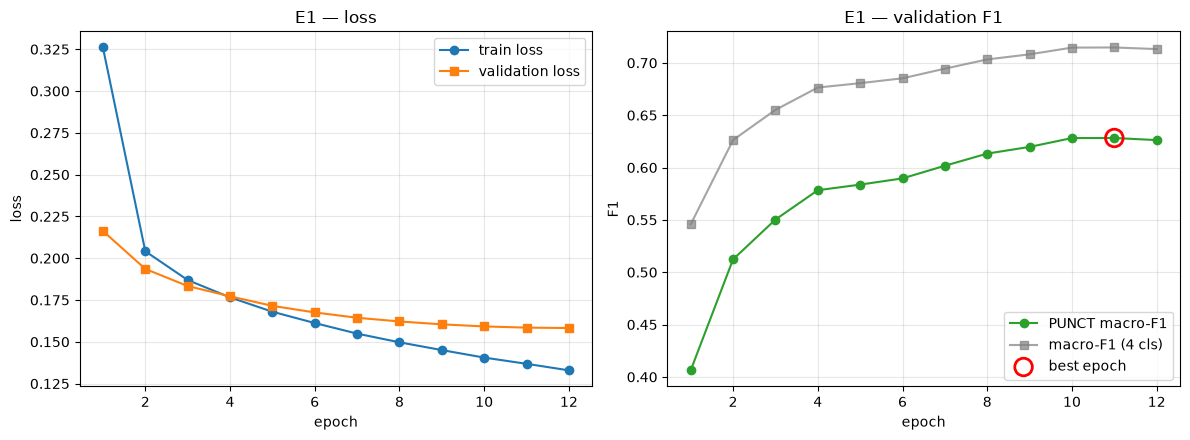

Saved: outputs\experiments\E1\training_curves.png


,epoch,train_loss,val_loss,val_accuracy,val_punctuation_macro_f1,val_f1_COMMA,val_f1_PERIOD,val_f1_QUESTION,learning_rate,epoch_seconds,is_best
0,1,0.32606,0.21631,0.92766,0.40627,0.24633,0.51238,0.46009,0.001,16.17,1
1,2,0.20417,0.19359,0.93401,0.51228,0.37020,0.61734,0.54929,0.001,19.52,1
2,3,0.18694,0.18337,0.93651,0.55029,0.41373,0.61913,0.61800,0.001,19.12,1
3,4,0.17658,0.17721,0.93831,0.57834,0.43409,0.65106,0.64988,0.001,21.59,1
4,5,0.16799,0.17150,0.94000,0.58369,0.44500,0.65384,0.65223,0.001,17.38,1
5,6,0.16123,0.16757,0.94142,0.58965,0.43758,0.66664,0.66472,0.001,15.49,1
6,7,0.15490,0.16438,0.94240,0.60173,0.46287,0.67227,0.67005,0.001,15.62,1
7,8,0.14970,0.16217,0.94313,0.61333,0.47157,0.67799,0.69043,0.001,15.54,1
8,9,0.14505,0.16045,0.94371,0.61973,0.48811,0.67424,0.69684,0.001,15.54,1
9,10,0.14056,0.15920,0.94416,0.62816,0.49832,0.68456,0.70161,0.001,15.55,1


In [ ]:
%matplotlib inline
curve_path = artifacts.plot_training_curves(show=True)
print("Saved:", curve_path)

history_df = pd.read_csv(artifacts.path("training_history.csv"))
display(history_df[[
    "epoch", "train_loss", "val_loss", "val_accuracy",
    "val_punctuation_macro_f1", "val_f1_COMMA", "val_f1_PERIOD", "val_f1_QUESTION",
    "learning_rate", "epoch_seconds", "is_best",
]].round(5))

## 9. Checkpoint tốt nhất

Mỗi thí nghiệm chỉ giữ checkpoint có validation Punctuation Macro-F1 cao nhất,
không mặc định dùng trạng thái của epoch cuối. `checkpoint_metadata.json` lưu
experiment id, cấu hình, label mapping, best epoch, validation score, hash dữ
liệu, seed và thông tin môi trường cần thiết để kiểm tra lại kết quả


In [ ]:
ckpt_dir = Path(trainer.checkpoints.checkpoint_dir)
meta     = read_json(ckpt_dir / "checkpoint_metadata.json")

print(f"Checkpoint directory: {ckpt_dir.relative_to(PROJECT_ROOT)}\n")
for f in sorted(ckpt_dir.iterdir()):
    print(f"  {f.name:<32}{f.stat().st_size / 1024:>12,.0f} KB")

print("\nMetadata:")
for key in ("experiment_id", "model_type", "model_name", "model_revision",
            "monitor_metric", "best_epoch", "best_score", "seed",
            "python_version", "torch_version", "transformers_version",
            "cuda_version", "gpu_name"):
    print(f"  {key:<22}: {meta.get(key)}")
print(f"  {'label2id':<22}: {meta.get('label2id')}")
print(f"  {'train content_sha256':<22}: {meta['data_hashes']['train']['content_sha256'][:32]}…")

Checkpoint directory: outputs\checkpoints\E1

  .gitkeep                                   0 KB
  checkpoint_metadata.json                   6 KB
  model.pt                              16,847 KB
  vocabulary.json                          457 KB

Metadata:
  experiment_id         : E1
  model_type            : bilstm
  model_name            : BiLSTM(emb=128, hidden=128x2)
  model_revision        : None
  monitor_metric        : punctuation_macro_f1
  best_epoch            : 11
  best_score            : 0.6282411379220462
  seed                  : 42
  python_version        : 3.12.4
  torch_version         : 2.13.0+cu126
  transformers_version  : 5.14.1
  cuda_version          : 12.6
  gpu_name              : NVIDIA GeForce RTX 4060 Laptop GPU
  label2id              : {'O': 0, 'COMMA': 1, 'PERIOD': 2, 'QUESTION': 3}
  train content_sha256  : 138983bc2761546f13c9520d5339b2ea…


## 10. Kết quả validation

Bảng metric và confusion matrix dưới đây thuộc checkpoint tốt nhất trên toàn
bộ validation split. Trong confusion matrix, hàng là nhãn đúng và cột là nhãn
dự đoán. Ví dụ, `gold_PERIOD / pred_O` biểu thị dấu chấm bị bỏ sót, còn
`gold_O / pred_COMMA` biểu thị dấu phẩy được thêm thừa


In [ ]:
print(format_metrics_table(best_metrics))

print("\nConfusion matrix (hàng = gold, cột = predicted)")
cm_df = pd.DataFrame(
    best_metrics["confusion_matrix"],
    index=[f"gold_{l}" for l in LABELS],
    columns=[f"pred_{l}" for l in LABELS],
)
display(cm_df)

print("Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):")
display((cm_df.div(cm_df.sum(axis=1), axis=0) * 100).round(2))

label       precision    recall        f1     support
-----------------------------------------------------
O              0.9618    0.9867    0.9741   1,800,593
COMMA          0.6599    0.3979    0.4964      91,818
PERIOD         0.7397    0.6403    0.6865      74,008
QUESTION       0.7086    0.6952    0.7018      10,987
-----------------------------------------------------
accuracy       0.9448
macro F1       0.7147   (all 4 classes)
PUNCT-F1       0.6282   <-- model selection metric (COMMA/PERIOD/QUESTION)

Confusion matrix (hàng = gold, cột = predicted)


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,1776607,13351,9254,1381
gold_COMMA,48047,36534,6682,555
gold_PERIOD,20040,5373,47390,1205
gold_QUESTION,2503,109,737,7638


Tỉ lệ theo hàng (recall của mỗi lớp nằm trên đường chéo):


,pred_O,pred_COMMA,pred_PERIOD,pred_QUESTION
gold_O,98.67,0.74,0.51,0.08
gold_COMMA,52.33,39.79,7.28,0.60
gold_PERIOD,27.08,7.26,64.03,1.63
gold_QUESTION,22.78,0.99,6.71,69.52


## 11. Kết quả theo từng lớp

- Precision phản ánh mức độ model thêm dấu câu không đúng vị trí
- Recall phản ánh số dấu câu thật bị bỏ sót
- F1 cân bằng precision và recall
- Support là số token mang nhãn tương ứng trong validation

Các chỉ số theo lớp hữu ích khi đánh giá ảnh hưởng của class weight,
vì một chiến lược có thể tăng recall cho lớp hiếm nhưng đồng thời làm giảm
precision


In [ ]:
per_class_df = pd.read_csv(artifacts.path("per_class_validation_metrics.csv"))
display(per_class_df)

pc = best_metrics["per_class"]
print("Punctuation Macro-F1 = mean of the three punctuation F1 scores:")
print(f"  F1_COMMA    = {pc['COMMA']['f1']:.6f}")
print(f"  F1_PERIOD   = {pc['PERIOD']['f1']:.6f}")
print(f"  F1_QUESTION = {pc['QUESTION']['f1']:.6f}")
print(f"  ---------------------------")
print(f"  PUNCT-F1    = {best_metrics['punctuation_macro_f1']:.6f}")

,label,precision,recall,f1,support,tp,fp,fn
0,O,0.961785,0.986679,0.974073,1800593.0,1776607.0,70590.0,23986.0
1,COMMA,0.659852,0.397896,0.496436,91818.0,36534.0,18833.0,55284.0
2,PERIOD,0.739741,0.640336,0.686458,74008.0,47390.0,16673.0,26618.0
3,QUESTION,0.708600,0.695185,0.701829,10987.0,7638.0,3141.0,3349.0
4,PUNCTUATION_MACRO_F1,NaN,NaN,0.628241,NaN,NaN,NaN,NaN
5,MACRO_F1_ALL_CLASSES,NaN,NaN,0.714699,NaN,NaN,NaN,NaN
6,ACCURACY,NaN,NaN,0.944757,NaN,NaN,NaN,NaN


Punctuation Macro-F1 = mean of the three punctuation F1 scores:
  F1_COMMA    = 0.496436
  F1_PERIOD   = 0.686458
  F1_QUESTION = 0.701829
  ---------------------------
  PUNCT-F1    = 0.628241


## 12. Ví dụ dự đoán trên validation

Phần này nạp lại checkpoint tốt nhất và dự đoán một số mẫu validation để đối
chiếu văn bản gold với đầu ra của model. Viết hoa đầu câu chỉ phục vụ hiển thị;
model trong dự án chỉ dự đoán dấu câu, không dự đoán capitalization


In [ ]:
best_model, _ = load_model_from_checkpoint(ckpt_dir, device=device)

from torch.utils.data import DataLoader
from src.data.dataset import BiLSTMDataset, collate_bilstm

sample_examples = validation_examples[:24]
sample_loader = DataLoader(
    BiLSTMDataset(sample_examples, vocab),
    batch_size=8, shuffle=False, collate_fn=collate_bilstm,
)

predictions = predict_word_labels(best_model, sample_loader, device=device, use_amp=trainer.use_amp)
rows = sample_predictions(best_model, sample_examples, predictions, n=8)

for r in rows[:5]:
    print(f"--- {r['id']}  ({r['num_words']} từ, token accuracy {r['token_accuracy']:.1%})")
    print(f"  input : {r['input_text'][:150]}")
    print(f"  gold  : {r['gold_text'][:150]}")
    print(f"  pred  : {r['predicted_text'][:150]}\n")

artifacts.write_sample_predictions(rows)
display(pd.DataFrame(rows)[["id", "num_words", "token_accuracy"]])

--- validation_000001  (136 từ, token accuracy 94.9%)
  input : bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em em đi ngoài thế nào em con đi ngoài bình thường ạ con đi khámbs bảo là không 
  gold  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá. Chào em em đi ngoài thế nào em? Con đi ngoài bình thường ạ con đi khámbs bảo là khôn
  pred  : Bác sĩ ơibụng của con bị đầy hơicon phải làm thế nào ạcon sợ quá chào em em đi ngoài thế nào em con đi ngoài bình thường ạ con đi khámbs bảo là không 

--- validation_000002  (133 từ, token accuracy 96.2%)
  input : vợ chồng em có quan hệ và hoạt động hơi mạnh ngày hôm sau em cảm thấy vùng bụng dưới bị xốn lấy tay sờ vào vùng kín thì cảm nhận được dây vòng dài hơn
  gold  : Vợ chồng em có quan hệ và hoạt động hơi mạnh, ngày hôm sau em cảm thấy vùng bụng dưới bị xốn, lấy tay sờ vào vùng kín thì cảm nhận được dây vòng dài h
  pred  : Vợ chồng em có quan hệ và hoạt động hơi mạnh. Ngày hôm sau em cảm thấy vùng 

,id,num_words,token_accuracy
0,validation_000001,136,0.948529
1,validation_000002,133,0.962406
2,validation_000003,140,0.942857
3,validation_000004,133,0.947368
4,validation_000005,141,0.950355
5,validation_000006,130,0.976923
6,validation_000007,134,0.947761
7,validation_000008,148,0.966216


## 13. Lưu artifact

`experiment_summary.json` được ghi bằng metric thu được từ lần chạy hiện tại,
sau đó notebook liệt kê các file trong thư mục experiment và checkpoint.
Những artifact này là đầu vào cho bước so sánh model ở notebook 05


In [ ]:
summary_path = artifacts.write_summary(
    model="BiLSTM(emb=128, hidden=128x2)",
    weight_mode=config["loss"]["weight_mode"],
    best_epoch=result.best_epoch,
    best_score=result.best_score,
    checkpoint_path=ckpt_dir,
    extra={
        "best_validation_accuracy": best_metrics["accuracy"],
        "best_validation_macro_f1_all_classes": best_metrics["macro_f1"],
        "best_validation_f1_per_class": {
            lab: best_metrics["per_class"][lab]["f1"] for lab in LABELS
        },
        "total_training_seconds": round(result.total_seconds, 1),
        "evaluated_on": "validation.jsonl (official JointCapPunc dev split)",
        "test_split_used": False,
    },
)

print("Artifacts written by this notebook\n")
print(f"{'outputs/experiments/' + EXPERIMENT_ID:<45}")
for f in sorted(artifacts.dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")
print(f"\n{'outputs/checkpoints/' + EXPERIMENT_ID:<45}")
for f in sorted(ckpt_dir.iterdir()):
    print(f"   {f.name:<42}{f.stat().st_size / 1024:>10,.1f} KB")

print("\nexperiment_summary.json:")
print(json.dumps(read_json(summary_path), indent=2, ensure_ascii=False))

2026-08-09 21:48:09 | INFO    | src.training.artifacts | Experiment E1 COMPLETED: {'status': 'COMPLETED', 'experiment_id': 'E1', 'model': 'BiLSTM(emb=128, hidden=128x2)', 'weight_mode': 'none', 'best_epoch': 11, 'best_validation_punctuation_macro_f1': 0.6282411379220462, 'checkpoint_path': 'outputs/checkpoints/E1', 'monitor_metric': 'punctuation_macro_f1', 'num_epochs_completed': 12, 'completed_at_utc': '2026-08-09T14:48:09+00:00', 'best_validation_accuracy': 0.9447574246259999, 'best_validation_macro_f1_all_classes': 0.7146991206663476, 'best_validation_f1_per_class': {'O': 0.9740730688992513, 'COMMA': 0.4964364575194483, 'PERIOD': 0.6864584163220372, 'QUESTION': 0.7018285399246531}, 'total_training_seconds': 202.6, 'evaluated_on': 'validation.jsonl (official JointCapPunc dev split)', 'test_split_used': False}
Artifacts written by this notebook

outputs/experiments/E1                       
   best_validation_metrics.json                     1.6 KB
   config.json                      

## 14. Hoàn tất E1

Cell kiểm tra cuối xác nhận các artifact bắt buộc đã được tạo và
`experiment_summary.json` có trạng thái `COMPLETED`. Khi phân tích E1,
cần lưu ý ba điểm: Punctuation Macro-F1 của baseline, F1 của lớp
`QUESTION` và tỷ lệ `<UNK>` trên validation

Các file chính gồm checkpoint E1, training history, validation metric,
per-class metric, confusion matrix và training curves


In [ ]:
expected = [
    artifacts.path("config.json"),
    artifacts.path("training_history.csv"),
    artifacts.path("best_validation_metrics.json"),
    artifacts.path("per_class_validation_metrics.csv"),
    artifacts.path("validation_confusion_matrix.csv"),
    artifacts.path("environment.json"),
    artifacts.path("data_hashes.json"),
    artifacts.path("experiment_summary.json"),
    artifacts.path("training_curves.png"),
    ckpt_dir / "checkpoint_metadata.json",
]
ok = True
for path in expected:
    exists = path.exists()
    ok &= exists
    print(f"  [{'OK  ' if exists else 'MISS'}] {path.relative_to(PROJECT_ROOT)}")

summary = read_json(artifacts.path("experiment_summary.json"))
status_ok = summary.get("status") == "COMPLETED"
print(f"\n  [{'OK  ' if status_ok else 'MISS'}] experiment_summary.json status = {summary.get('status')}")

print("\n" + "=" * 78)
if ok and status_ok:
    print(f"{EXPERIMENT_ID} COMPLETED — validation {MONITOR_METRIC} = "
          f"{summary['best_validation_punctuation_macro_f1']:.6f} at epoch "
          f"{summary['best_epoch']}")
    print("Test split was never loaded in this notebook.")
else:
    print(f"{EXPERIMENT_ID} INCOMPLETE — re-run the notebook from the top.")
print("=" * 78)

  [OK  ] outputs\experiments\E1\config.json
  [OK  ] outputs\experiments\E1\training_history.csv
  [OK  ] outputs\experiments\E1\best_validation_metrics.json
  [OK  ] outputs\experiments\E1\per_class_validation_metrics.csv
  [OK  ] outputs\experiments\E1\validation_confusion_matrix.csv
  [OK  ] outputs\experiments\E1\environment.json
  [OK  ] outputs\experiments\E1\data_hashes.json
  [OK  ] outputs\experiments\E1\experiment_summary.json
  [OK  ] outputs\experiments\E1\training_curves.png
  [OK  ] outputs\checkpoints\E1\checkpoint_metadata.json

  [OK  ] experiment_summary.json status = COMPLETED

E1 COMPLETED — validation punctuation_macro_f1 = 0.628241 at epoch 11
Test split was never loaded in this notebook.
